In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.shape

(100000, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [5]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
df = pd.get_dummies(
    df,
    columns=["gender", "smoking_history"],
    drop_first=True
)

df.head()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [7]:
X = df.drop("diabetes", axis=1)

y = df["diabetes"]

In [8]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (100000, 13)
y Shape: (100000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
model = Sequential()

model.add(Dense(16, activation="sigmoid", input_shape=(X_train.shape[1],)))

model.add(Dense(8, activation="sigmoid"))

model.add(Dense(1, activation="sigmoid"))

C:\Users\rites\.conda\envs\py311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)               ┃ Output Shape        ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense (Dense)              │ (None, 16)          │        224 │
├────────────────────────────┼─────────────────────┼────────────┤
│ dense_1 (Dense)            │ (None, 8)           │        136 │
├────────────────────────────┼─────────────────────┼────────────┤
│ dense_2 (Dense)            │ (None, 1)           │          9 │
└────────────────────────────┴─────────────────────┴────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9277 - loss: 0.2110 - val_accuracy: 0.9571 - val_loss: 0.1303
Epoch 2/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9593 - loss: 0.1225 - val_accuracy: 0.9591 - val_loss: 0.1208
Epoch 3/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9597 - loss: 0.1186 - val_accuracy: 0.9602 - val_loss: 0.1193
Epoch 4/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9601 - loss: 0.1168 - val_accuracy: 0.9600 - val_loss: 0.1175
Epoch 5/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9605 - loss: 0.1156 - val_accuracy: 0.9599 - val_loss: 0.1164
Epoch 6/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9609 - loss: 0.1147 - val_accuracy: 0.9602 - val_loss: 0.1156
Epoch 7/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9605 - loss: 0.1140 - val_accuracy: 0.9606 - val_loss: 0.1148
Epoch 8/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9604 - loss: 0.1134 - 

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9617 - loss: 0.1077
Test Loss: 0.10766223073005676
Test Accuracy: 0.9617499709129333


In [16]:
y_probability = model.predict(X_test)

y_pred = (y_probability >= 0.5).astype(int)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("ANN Accuracy:", accuracy)

ANN Accuracy: 0.96175


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.90      0.62      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.93      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [19]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18177   123]
 [  642  1058]]


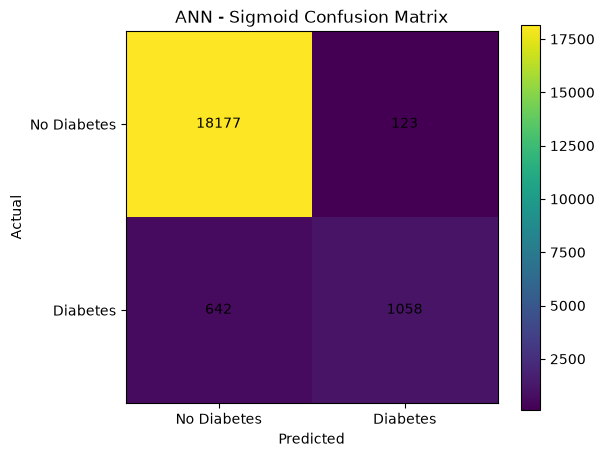

In [20]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("ANN - Sigmoid Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.show()

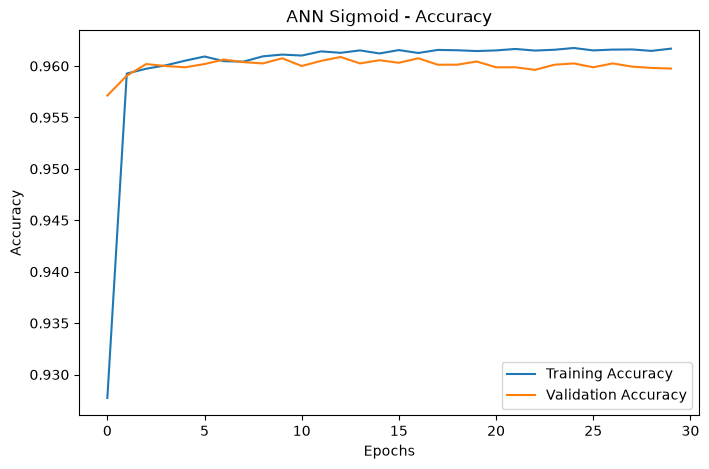

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Sigmoid - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

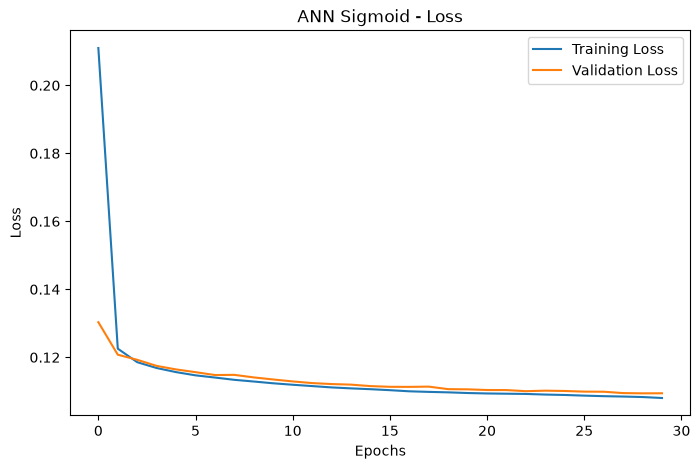

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Sigmoid - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [23]:
Dense(1, activation="sigmoid")

<Dense name=dense_3, built=False>

In [24]:
loss="binary_crossentropy"

In [25]:
loss

'binary_crossentropy'

In [26]:
import joblib

# Save ANN model
model.save("diabetes_ann_model.keras")

# Save scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

# Save training columns
joblib.dump(
    X.columns.tolist(),
    "columns.pkl"
)

print("All files saved successfully!")

All files saved successfully!
